In [1]:
import pandas as pd
import os
import sys

# Add the path to the src directory (two levels up)
sys.path.append(os.path.abspath('../../'))
from src.data_processor import *
from src.database_utils import CFSDatabase
from src.data_loader import DataLoader
from src.plotting import *
from src.utilities import get_first_forecast_month

In [2]:
# Directory where the repository is cloned
local_path = '/Users/ljob/Desktop/'

# Path to data directory
input_dir = local_path + 'cnbs-predictor/data/'

# Path to save CNBS forecast output to a database
cnbs_database = local_path + 'Data/cnbs_forecast.db'
cnbs_table = 'cnbs_forecast'

In [3]:
start_date = get_first_forecast_month()

First forecast month: 2026-04


In [4]:
prob = DataLoader().lake_probabilities(local_path + "cnbs-predictor/data/probabilities/", units="mm")
prob_aligned = align_prob_with_start_date(prob, start_date)

In [5]:
# Load CNBS predictions
data = CFSDatabase(cnbs_database, cnbs_table).load()
df_filtered = ForecastTransformer(data).filter(start_date)

**Plotting the 12-Month Great Lakes Net Basin Supply (NBS) Forecasts**

This cell generates a **4×4 grid of subplots** visualizing precipitation, evaporation, runoff, and total NBS forecasts for each of the four Great Lakes basins (Superior, Michigan-Huron, Erie, Ontario).  

### Key Steps:

1. **Color Assignment**  
   - Assigns a distinct color to each model using a predefined color list (`custom_colors`).  
   - Raises an error if the number of models exceeds available colors.

2. **Data Setup**  
   - Defines the plotting order of 16 forecast variables (4 components × 4 lakes).  
   - Creates subplot grid (`fig, axs`) for visual arrangement.  
   - Tracks separate y-axis ranges for precipitation, evaporation, and runoff (columns 0–2) versus total NBS (column 3).

3. **Plotting for Each Variable**  
   - For each component/lake combination:
     - Computes **95% confidence intervals** using the 2.5th and 97.5th percentiles.
     - Plots the mean forecast for each model with unique colors and markers.
     - Shades the 95% confidence interval region in gray (`fill_between`).
     - Adds horizontal zero reference lines, gridlines, and shared y-ticks.
     - Dynamically adjusts y-axis limits so that subplots share consistent scaling.

4. **Formatting**  
   - Adds component titles across the top row (Precipitation, Evaporation, Runoff, Total NBS).
   - Labels y-axes by lake name for the first column.
   - Formats x-axis dates (`%m-%Y`) for the bottom row, rotating labels for readability.

5. **Final Layout & Output**  
   - Synchronizes y-axis limits across similar variable types.
   - Sets the plot’s main title: *"Great Lakes 12-Month CNBS [mm] Forecast"*.
   - Adds a legend to the top-right subplot.
   - Saves the figure as `CNBS_forecast.png` in the forecast output directory.
   - Displays the final figure.

**Purpose:**  
This visualization provides a **multi-model ensemble view** of the Great Lakes’ hydrological forecast components over the next 12 months, allowing easy comparison of models, seasonal cycles, and uncertainty ranges.

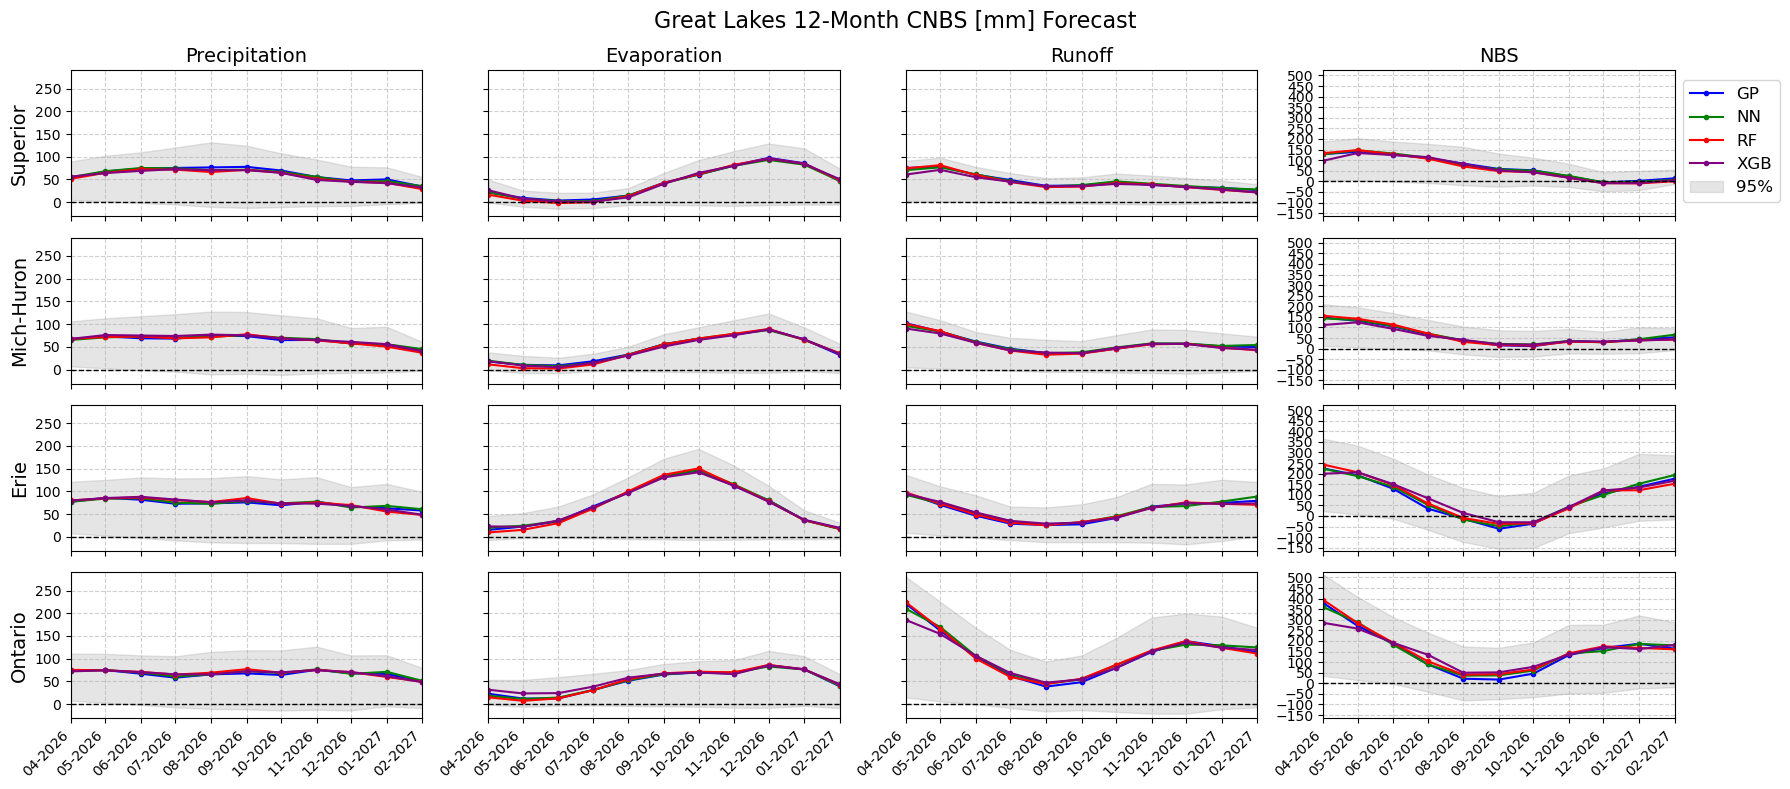

In [6]:
plot_cnbs_forecast(df_filtered, local_path + 'cnbs-predictor/forecast/figures/CNBS_forecast.png')

**Interactive 4×4 Grid of Great Lakes 12-Month NBS Forecasts**

This section uses **Plotly** to create a fully interactive **4×4 subplot grid** that visualizes the mean forecasts and uncertainty ranges for precipitation, evaporation, runoff, and total CNBS across the four Great Lakes basins.

In [7]:
plot_cnbs_forecast_interactive(df_filtered, local_path + 'cnbs-predictor/forecast/figures/CNBS_forecast.html')

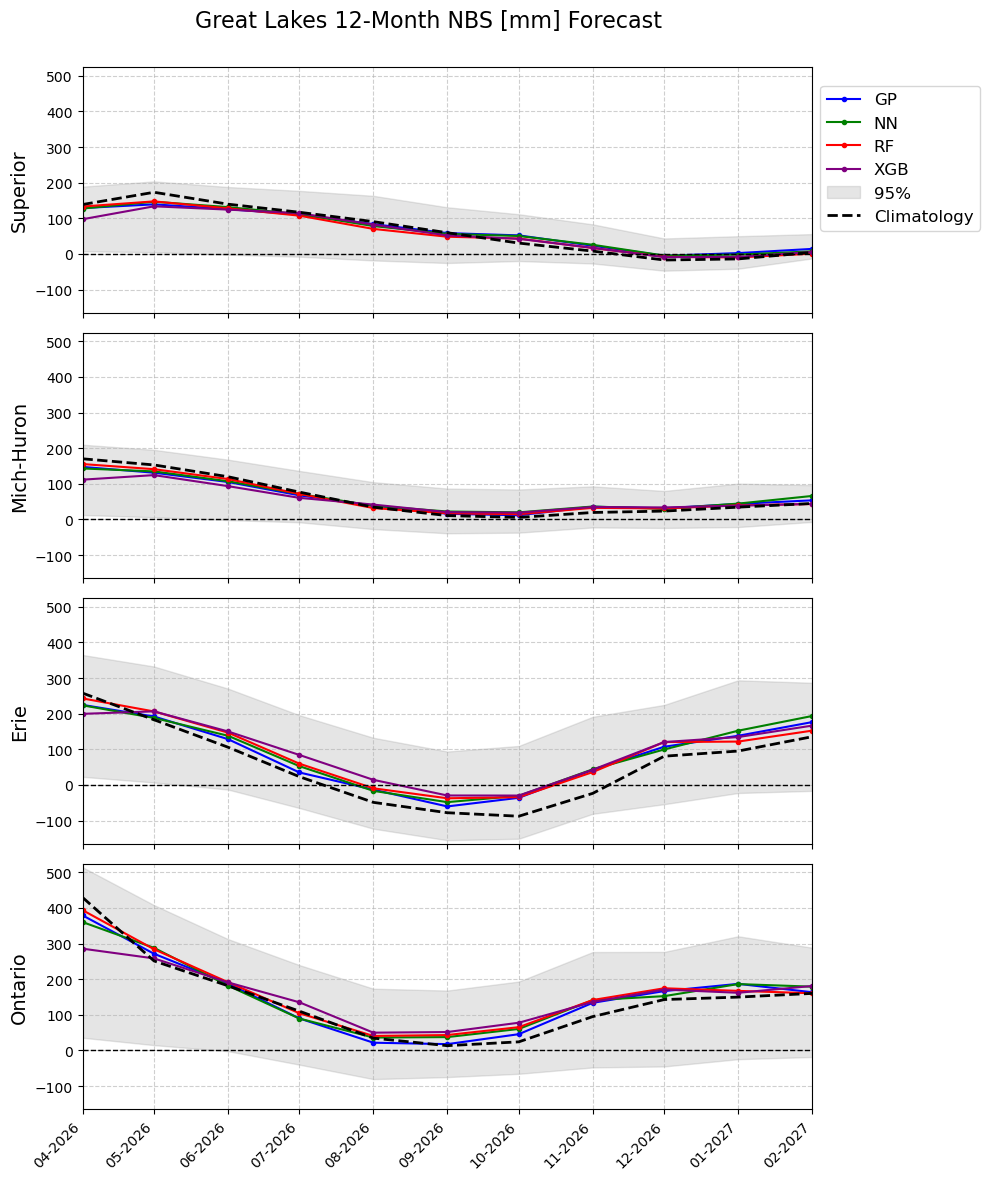

In [8]:
plot_nbs_forecast(df_filtered, prob_aligned, local_path + 'cnbs-predictor/forecast/figures/NBS_forecast.png')

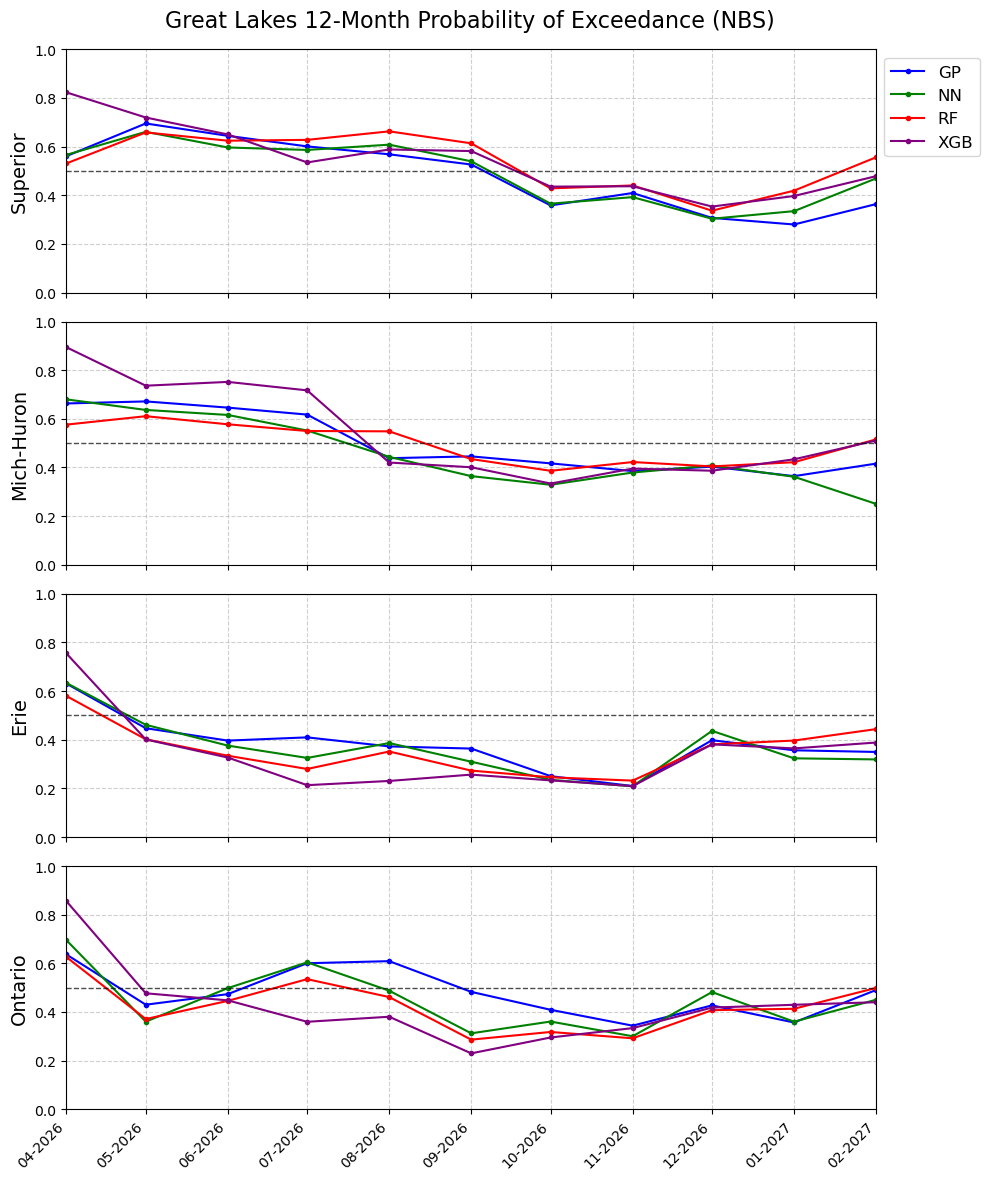

In [9]:
plot_prob_exceed(df_filtered, prob_aligned, local_path + 'cnbs-predictor/forecast/figures/probability_of_exceed.png')